# Stock Replenishment Example

A small, basic reorder-point replenishment example over 3 articles: calibrate a
safety-stock factor per article against the backtest window, then simulate the forecast
window with a `ReorderPointTrigger` policy.

**Scope note (Task 14 rewrite):** the original notebook also swept an aggregation window
via `optimize_aggregation_and_service_level_factors`/`simulate_replenishment_with_aggregation`,
neither of which was ported into this repo (see `io_.py`'s module docstring), so that
section is dropped here.

In [1]:
from dataclasses import replace
import random

import pandas as pd

from replenishment.io_ import (
    generate_standard_simulation_rows, standard_simulation_rows_to_dataframe,
    split_standard_simulation_rows, replenishment_decision_rows_to_dataframe,
    ReplenishmentDecisionRow,
)
from replenishment.calibration import optimize
from replenishment.simulation import simulate_replenishment
from replenishment.policy import ReplenishmentPolicy
from replenishment.timeseries import TimeSeries
from replenishment.strategies.safety_stock import SqrtHorizonSafetyStock
from replenishment.strategies.order_trigger import ReorderPointTrigger
from replenishment.viz import plot_replenishment_decisions

### Policy cadence parameters (review cycle + forecast horizon)

Set the order cadence (**review_period**) and the coverage window (**forecast_horizon**,
excluding lead time). The policy uses a total horizon of **lead_time + forecast_horizon**.

In [2]:
review_period = 1
forecast_horizon = 1

## Example: optimize service level and review window

In [3]:
rows = generate_standard_simulation_rows(
    n_unique_ids=3,
    periods=60,
    forecast_start_period=30,
    history_mean=20.0,
    history_std=5.0,
    forecast_mean=18.0,
    forecast_std=4.0,
    lead_time=3,
    initial_on_hand=25,
    current_stock=25,
    holding_cost_per_unit=1,
    stockout_cost_per_unit=5,
    order_cost_per_order=10,
    seed=7,
)

backtest_rows, evaluation_rows = split_standard_simulation_rows(rows)

rng = random.Random(7)
def _sample_int(mean: float, std: float) -> int:
    return max(0, int(round(rng.gauss(mean, std))))

evaluation_rows = [
    replace(row, actuals=_sample_int(20.0, 5.0), demand=_sample_int(20.0, 5.0))
    for row in evaluation_rows
]

rows_df = standard_simulation_rows_to_dataframe(backtest_rows + evaluation_rows, library="pandas")

In [4]:
def _group_by_article(rows):
    grouped = {}
    for row in rows:
        grouped.setdefault(row.unique_id, []).append(row)
    for uid in grouped:
        grouped[uid].sort(key=lambda r: r.ds)
    return grouped

In [5]:
candidate_service_levels = [0.8, 0.9, 0.95]

backtest_by_article = _group_by_article(backtest_rows)
forecast_by_article = _group_by_article(evaluation_rows)

decision_rows = []
calibration_results = {}
for unique_id, article_backtest in backtest_by_article.items():
    demand = [r.demand for r in article_backtest]
    actuals = [r.actuals for r in article_backtest]
    forecast_values = [r.forecast for r in article_backtest]
    lead_time = article_backtest[0].lead_time

    def candidate_builder(factor, forecast_values=forecast_values, actuals=actuals, lead_time=lead_time):
        return ReplenishmentPolicy.reorder_point(
            forecast=TimeSeries.from_values(forecast_values),
            actuals=TimeSeries.from_values(actuals),
            safety_stock=SqrtHorizonSafetyStock(factor=factor),
            lead_time=lead_time, review_period=review_period, forecast_horizon=forecast_horizon,
        )

    result = optimize(
        candidate_builder=candidate_builder, candidate_values=candidate_service_levels,
        periods=len(article_backtest), demand=demand, initial_on_hand=article_backtest[0].initial_on_hand,
        lead_time=lead_time, holding_cost_per_unit=article_backtest[0].holding_cost_per_unit,
        stockout_cost_per_unit=article_backtest[0].stockout_cost_per_unit,
        order_cost_per_order=article_backtest[0].order_cost_per_order,
    )
    calibration_results[unique_id] = result

    article_forecast_rows = forecast_by_article.get(unique_id, [])
    if not article_forecast_rows:
        continue
    eval_policy = candidate_builder(
        result.best_value, forecast_values=[r.forecast for r in article_forecast_rows], actuals=actuals,
    )
    current_stock = article_forecast_rows[0].current_stock
    simulation = simulate_replenishment(
        periods=len(article_forecast_rows), demand=[r.demand for r in article_forecast_rows],
        initial_on_hand=current_stock, lead_time=lead_time, policy=eval_policy,
        holding_cost_per_unit=article_forecast_rows[0].holding_cost_per_unit,
        stockout_cost_per_unit=article_forecast_rows[0].stockout_cost_per_unit,
        order_cost_per_order=article_forecast_rows[0].order_cost_per_order,
    )
    for row, snapshot in zip(article_forecast_rows, simulation.snapshots):
        decision_rows.append(ReplenishmentDecisionRow(
            unique_id=unique_id, ds=row.ds, quantity=snapshot.order_placed,
            demand=snapshot.demand, incoming_stock=snapshot.received,
            starting_on_hand=snapshot.starting_on_hand, ending_on_hand=snapshot.ending_on_hand,
            on_order=snapshot.on_order, backorders=snapshot.backorders, sigma=result.best_value,
        ))

eval_decisions_df = replenishment_decision_rows_to_dataframe(decision_rows, library="pandas")
eval_decisions_df.head()

,unique_id,ds,quantity,demand,forecast_quantity,forecast_quantity_lead_time,reorder_point,order_up_to,incoming_stock,starting_stock,...,current_stock,on_order,backorders,missed_sales,sigma,aggregation_window,review_period,forecast_horizon,rmse_window,percentile_target
0,A,2026-06-19,57,23,None,None,None,None,0,None,...,None,57,0,None,0.95,None,None,None,None,None
1,A,2026-07-19,0,18,None,None,None,None,0,None,...,None,57,16,None,0.95,None,None,None,None,None
2,A,2026-08-18,0,19,None,None,None,None,0,None,...,None,57,19,None,0.95,None,None,None,None,None
3,A,2026-09-17,34,22,None,None,None,None,57,None,...,None,34,0,None,0.95,None,None,None,None,None
4,A,2026-10-17,23,21,None,None,None,None,0,None,...,None,57,0,None,0.95,None,None,None,None,None


### Plot

<Axes: title={'center': 'Replenishment for A'}, xlabel='Date', ylabel='Units'>

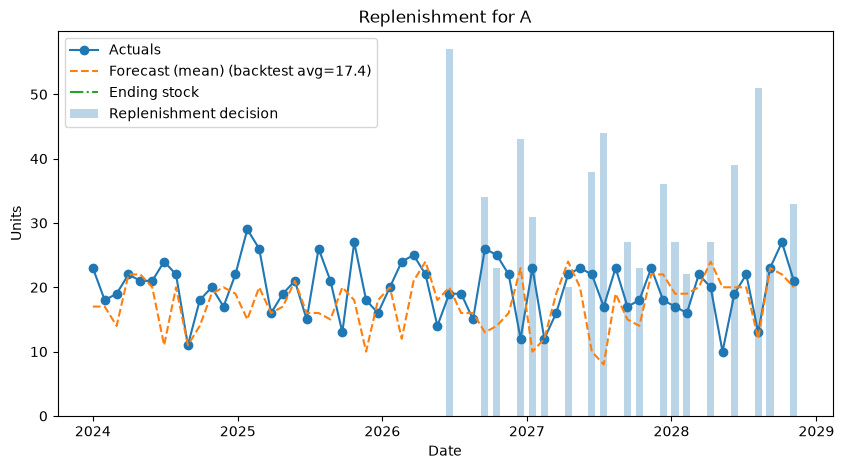

In [6]:
example_id = eval_decisions_df["unique_id"].iloc[0]
plot_replenishment_decisions(rows_df, eval_decisions_df, unique_id=example_id)